<a href='https://www.darshan.ac.in/'> <img src='https://www.darshan.ac.in/Content/media/DU_Logo.svg' width="250" height="300"/></a>
<pre>
<center><b><h1>Machine Learning - 2301CS621</b></center>

<center><b><h1>Lab - 5 Multiple Linear Regression - Polynomial Regression</b></center>
<pre>    

# Importing the libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
import warnings
warnings.filterwarnings('ignore')

# Importing the libraries

In [2]:
df = pd.read_csv("Position_Salaries.csv")

In [3]:
df

,Position,Level,Salary
0,Business Analyst,1,45000
1,Junior Consultant,2,50000
2,Senior Consultant,3,60000
3,Manager,4,80000
4,Country Manager,5,110000
5,Region Manager,6,150000
6,Partner,7,200000
7,Senior Partner,8,300000
8,C-level,9,500000
9,CEO,10,1000000


# Plot the data using scatter plot

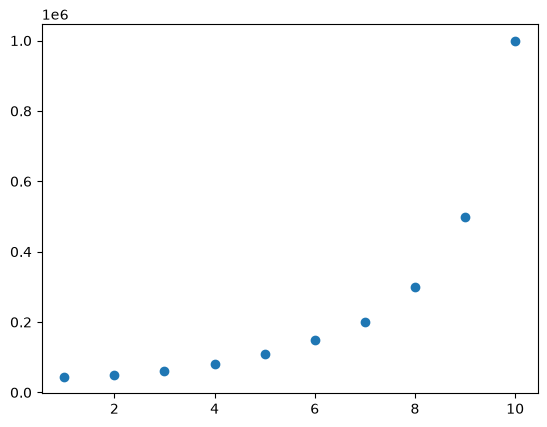

In [4]:
plt.scatter(df['Level'],df['Salary'])

In [5]:
x = df[['Level']]
y = df['Salary']
x

,Level
0,1
1,2
2,3
3,4
4,5
5,6
6,7
7,8
8,9
9,10


# Splitting the dataset into the Training set and Test set

In [6]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size = 0.3, random_state = 42)
X_train

,Level
0,1
7,8
2,3
9,10
4,5
3,4
6,7


In [7]:
X_test

,Level
8,9
1,2
5,6


# Fitting Linear Regression to the dataset

In [8]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()

In [9]:
model.fit(X_train, y_train)

LinearRegression()

# Predict the x_test using Linear Model

In [10]:
y_predict_linear = model.predict(X_test)
y_predict_linear

array([575160.89108911, -49554.45544554, 307425.74257426])

# Visualising the Linear Regression results

In [11]:
y_test

8    500000
1     50000
5    150000
Name: Salary, dtype: int64

In [12]:
y_predict_linear

array([575160.89108911, -49554.45544554, 307425.74257426])

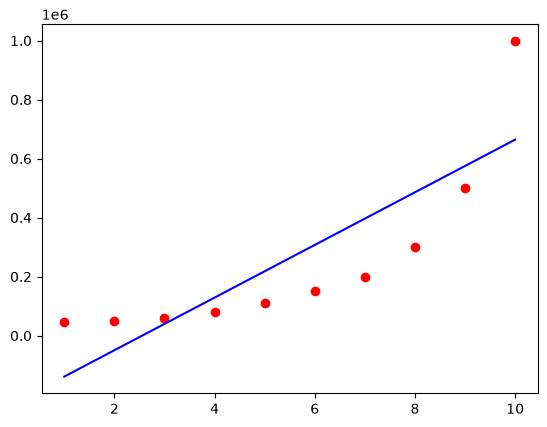

In [13]:
plt.scatter(x,y,color='red')
plt.plot(x,model.predict(x),color='Blue')

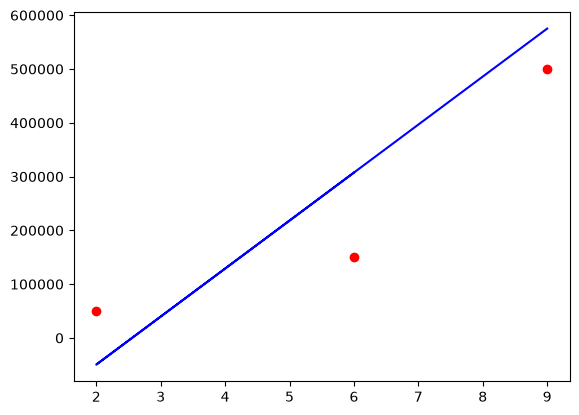

In [14]:
plt.scatter(X_test,y_test,color='red',label='Actual Data')
plt.plot(X_test,y_predict_linear,color='Blue',label='Predicted Data')

In [15]:
from sklearn.metrics import mean_squared_error

In [16]:
mean_squared_error(y_test,y_predict_linear)

np.float64(13447704524.474731)

# Fitting Polynomial Regression to the dataset

## import  PolynomialFeatures

In [17]:
from sklearn.preprocessing import PolynomialFeatures

## create PolynomialFeatures of degree 4

In [18]:
poly = PolynomialFeatures(degree = 4)

## Apply fit_transform to features

In [19]:
X_train_poly = poly.fit_transform(X_train)
x_test_poly = poly.transform(X_test)

## View new  Features

In [20]:
poly.fit_transform(x)

array([[1.000e+00, 1.000e+00, 1.000e+00, 1.000e+00, 1.000e+00],
       [1.000e+00, 2.000e+00, 4.000e+00, 8.000e+00, 1.600e+01],
       [1.000e+00, 3.000e+00, 9.000e+00, 2.700e+01, 8.100e+01],
       [1.000e+00, 4.000e+00, 1.600e+01, 6.400e+01, 2.560e+02],
       [1.000e+00, 5.000e+00, 2.500e+01, 1.250e+02, 6.250e+02],
       [1.000e+00, 6.000e+00, 3.600e+01, 2.160e+02, 1.296e+03],
       [1.000e+00, 7.000e+00, 4.900e+01, 3.430e+02, 2.401e+03],
       [1.000e+00, 8.000e+00, 6.400e+01, 5.120e+02, 4.096e+03],
       [1.000e+00, 9.000e+00, 8.100e+01, 7.290e+02, 6.561e+03],
       [1.000e+00, 1.000e+01, 1.000e+02, 1.000e+03, 1.000e+04]])

## Fitting Polynomial Regression to the dataset

In [21]:
poly_model = LinearRegression()

In [22]:
poly_model.fit(X_train_poly,y_train)

LinearRegression()

# Create Grid for higher resolution and smoother curve

In [ ]:
import numpy as np
x1 = np.arange(1,10.1,0.1).reshape(-1,1)
x1


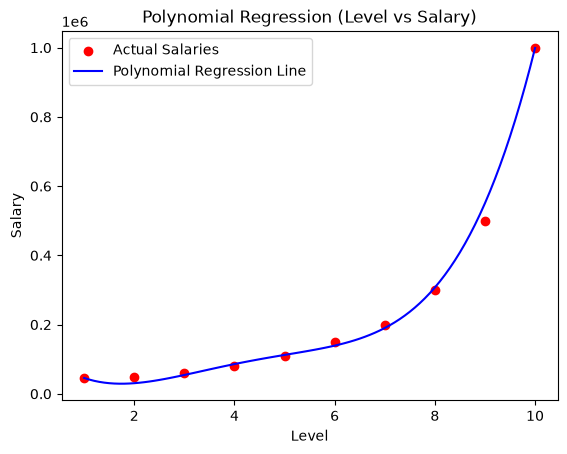

In [31]:
# plt.figure(dpi=900) 
plt.scatter(x, y, color = 'red', label = 'Actual Salaries')
plt.plot(x1, poly_model.predict(poly.transform(x1)), color = 'blue', 
         label = 'Polynomial Regression Line')
plt.title('Polynomial Regression (Level vs Salary)')
plt.xlabel('Level')
plt.ylabel('Salary')
plt.legend()

# Predict the x_test using Polynomial Regression

In [25]:
y_predict_poly = poly_model.predict(x_test_poly)
y_predict_poly

array([550738.27849069,  30679.16278163, 139190.58942538])

# Visualising the Linear Regression results

In [26]:
y_test

8    500000
1     50000
5    150000
Name: Salary, dtype: int64

In [27]:
y_predict_linear

array([575160.89108911, -49554.45544554, 307425.74257426])

In [28]:
y_predict_poly

array([550738.27849069,  30679.16278163, 139190.58942538])

In [ ]:
plt.scatter(x,y)
plt.plot(x,model.predict(x), c= 'r')
plt.plot(x,poly_model.predict(poly.fit_transform(x)),c ='g')

In [32]:
mse_poly = mean_squared_error(y_test, y_predict_poly)
print(f"Mean Squared Error for Polynomial Regression: {mse_poly}")

Mean Squared Error for Polynomial Regression: 1021503670.6628565
